# Проверка гипотез в Python и результаты А/Б-теста

## Часть 1. Проверка гипотезы в Python и составление аналитической записки

- Автор: Кривенко Виктория Александровна
- Дата:01.09.2026

## Цели и задачи проекта

**Цель проекта** — проверить гипотезу о различии активности пользователей из Москвы и Санкт-Петербурга, а также оценить корректность проведения и результаты A/B-теста нового интерфейса интернет-магазина BitMotion Kit.

**Задачи проекта:**
- Загрузить и изучить данные о пользовательской активности в Яндекс Книгах.
- Проверить данные на наличие дубликатов и сравнить пользователей из Москвы и Санкт-Петербурга.
- Провести статистическую проверку гипотезы о различии среднего времени активности пользователей двух городов.
- Сформулировать выводы по результатам проверки гипотезы.
- Загрузить данные участников A/B-теста и пользовательских событий интернет-магазина.
- Проверить корректность проведения A/B-теста: распределение пользователей по группам, наличие пересечений и другие возможные проблемы.
- Рассчитать конверсию пользователей в покупку и оценить статистическую значимость различий между группами.
- Сформулировать рекомендации по результатам A/B-теста.


## Описание данных

**В первой части** проекта используются данные сервиса Яндекс Книги, содержащие информацию о пользователях из Москвы и Санкт-Петербурга и суммарном времени их чтения и прослушивания.

Файл `yandex_knigi_data.csv` содержит следующие поля:

`city` — город пользователя;<br>
`puid` — уникальный идентификатор пользователя;<br>
`hours` — суммарное количество часов активности пользователя.

**Во второй части** используются данные A/B-теста интернет-магазина BitMotion Kit.

Файл `ab_test_participants.csv` содержит информацию об участниках эксперимента:

`user_id` — идентификатор пользователя;<br>
`group` — экспериментальная группа;<br>
`ab_test` — название A/B-теста;<br>
`device` — устройство, с которого пользователь зарегистрировался.

Файл `ab_test_events.csv` содержит данные о пользовательских событиях:

`user_id` — идентификатор пользователя;<br>
`event_dt` — дата и время события;<br>
`event_name` — тип события;<br>
`details` — дополнительные сведения о событии.

## Содержимое проекта

#### Часть 1. Проверка гипотезы в Python
Загрузка данных и знакомство с ними.<br>
Проверка наличия дубликатов и изучение статистик пользователей.<br>
Формулировка и проверка гипотезы о различии среднего времени активности пользователей из Москвы и Санкт-Петербурга.<br>
Интерпретация результатов статистического теста.<br>
Подготовка аналитической записки.<br>

#### Часть 2. Анализ результатов A/B-тестирования
Определение целей исследования.<br>
Загрузка и проверка целостности данных.<br>
Проверка корректности проведения A/B-теста.<br>
Анализ пользовательской активности.<br>
Расчёт конверсии в покупку.<br>
Статистическая проверка различий между группами.<br>
Формулировка выводов и рекомендаций по результатам эксперимента.

## 1. Загрузка данных и знакомство с ними

Загрузим данные пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания) из файла `/datasets/yandex_knigi_data.csv`.

In [1]:
# импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

from statsmodels.stats.proportion import proportions_ztest

In [2]:
# сохраняем данные из датасета yandex_knigi_data.csv в датафрейм ya_knigi_data
ya_knigi_data = pd.read_csv('/datasets/yandex_knigi_data.csv')

In [3]:
# выводим первые строки датафрейма на экран
ya_knigi_data.head()

,Unnamed: 0,city,puid,hours
0,0,Москва,9668,26.167776
1,1,Москва,16598,82.111217
2,2,Москва,80401,4.656906
3,3,Москва,140205,1.840556
4,4,Москва,248755,151.326434


In [4]:
# знакомимся с данными
ya_knigi_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  8784 non-null   int64  
 1   city        8784 non-null   object 
 2   puid        8784 non-null   int64  
 3   hours       8784 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 274.6+ KB


In [5]:
# проверяем наличие дубликатов пользователей
ya_knigi_data['puid'].duplicated().sum()

244

Нужно проверить, почему эти дубликаты появились.  возможно, один пользователь просто имеет несколько записей.

Проверяем, не встречается ли один и тот же пользователь одновременно в Москве и Санкт-Петербурге, поскольку это могло бы нарушить независимость двух выборок:

In [6]:
# проверяем, в скольких городах представлен каждый пользователь
ya_knigi_data.groupby('puid')['city'].nunique().value_counts()

1    8296
2     244
Name: city, dtype: int64

В исходных данных обнаружено 244 пользователя, которые были представлены одновременно в Москве и Санкт-Петербурге.

In [7]:
# исключаем пользователей, представленных одновременно в Москве и Санкт-Петербурге
ya_knigi_data = ya_knigi_data[~ya_knigi_data['puid'].duplicated(keep=False)]

# проверяем, что после удаления у каждого пользователя остался только один город
ya_knigi_data.groupby('puid')['city'].nunique().value_counts()

1    8296
Name: city, dtype: int64

В результате первичного анализа датасета установлено, что он содержит 8 784 записи о пользователях из Москвы и Санкт-Петербурга. Пропущенных значений в данных нет. При проверке уникальности пользователей было обнаружено 244 пользователя, которые представлены одновременно в обоих городах.

Поскольку наличие одного пользователя в обеих выборках может нарушать независимость сравниваемых групп, такие записи были исключены из дальнейшего анализа. После очистки данных каждый пользователь представлен только в одном городе, поэтому данные можно использовать для дальнейшего сравнения активности пользователей из Москвы и Санкт-Петербурга.

## 2. Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуем статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [8]:
# разделяем пользователей на группы по городам
moscow = ya_knigi_data[ya_knigi_data['city'] == 'Москва']
spb = ya_knigi_data[ya_knigi_data['city'] == 'Санкт-Петербург']

# проверяем количество пользователей в каждой группе
print(f'Москва: {len(moscow)}')
print(f'Санкт-Петербург: {len(spb)}')

Москва: 5990
Санкт-Петербург: 2306


In [9]:
# сравниваем статистики активности пользователей в двух группах
print('Москва:')
print(moscow['hours'].describe())

print('\nСанкт-Петербург:')
print(spb['hours'].describe())

Москва:
count    5990.000000
mean       10.848192
std        36.925622
min         0.000022
25%         0.057042
50%         0.888232
75%         5.933439
max       857.209373
Name: hours, dtype: float64

Санкт-Петербург:
count    2306.000000
mean       11.264433
std        39.831755
min         0.000025
25%         0.060173
50%         0.875355
75%         6.138424
max       978.764775
Name: hours, dtype: float64


Поскольку у групп размеры сильно отличаются, а стандартные отклонения тоже немного различаются, используем t-тест Уэлча - он не требует равенства дисперсий.

In [10]:
# проводим односторонний t-тест Уэлча
alpha = 0.05 

stat, p_value = ttest_ind(
    spb['hours'],
    moscow['hours'],
    equal_var=False,
    alternative='greater'
)

print(f'p-value: {p_value}')

if p_value < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу')

p-value: 0.33179596018475044
Не отвергаем нулевую гипотезу


## 3. Аналитическая записка

Для проверки гипотезы был выбран односторонний t-тест Уэлча, так как он подходит для сравнения средних значений двух независимых выборок и не требует предположения о равенстве их дисперсий. Уровень статистической значимости составил α = 0,05.

Средняя активность пользователей в Санкт-Петербурге составила 11,26 часа, а в Москве — 10,85 часа. Несмотря на немного более высокое среднее значение в Санкт-Петербурге, по результатам теста получено p-value = 0,3318.

Поскольку p-value > 0,05, оснований отвергнуть нулевую гипотезу нет. Статистически значимых доказательств того, что пользователи из Санкт-Петербурга проводят в приложении больше времени, чем пользователи из Москвы, не обнаружено.

Одной из возможных причин результата может быть то, что фактическая разница в активности пользователей между городами слишком мала и может объясняться случайными колебаниями. Кроме того, на активность пользователей могут влиять другие факторы, например индивидуальные особенности поведения или предпочтения в использовании сервиса.

----

# Часть 2. Анализ результатов A/B-тестирования

Теперь вам нужно проанализировать другие данные. Представьте, что к вам обратились представители интернет-магазина BitMotion Kit, в котором продаются геймифицированные товары для тех, кто ведёт здоровый образ жизни. У него есть своя целевая аудитория, даже появились хиты продаж: эспандер со счётчиком и напоминанием, так и подстольный велотренажёр с Bluetooth.

В будущем компания хочет расширить ассортимент товаров. Но перед этим нужно решить одну проблему. Интерфейс онлайн-магазина слишком сложен для пользователей — об этом говорят отзывы.

Чтобы привлечь новых клиентов и увеличить число продаж, владельцы магазина разработали новую версию сайта и протестировали его на части пользователей. По задумке, это решение доказуемо повысит количество пользователей, которые совершат покупку.

Ваша задача — провести оценку результатов A/B-теста. В вашем распоряжении:

* данные о действиях пользователей и распределении их на группы,

* техническое задание.

Оцените корректность проведения теста и проанализируйте его результаты.

## 1. Описание цели исследования.



**Основная цель исследования** — оценить, приводит ли новая версия интерфейса интернет-магазина BitMotion Kit к увеличению конверсии пользователей в покупку.

Для этого необходимо:<br>
проверить корректность проведения A/B-теста и распределения пользователей по группам;<br>
сравнить конверсию в покупку в контрольной и тестовой группах;<br>
определить, является ли различие между группами статистически значимым;<br>
на основании результатов теста сделать вывод о целесообразности внедрения новой версии сайта.

## 2. Загрузка данных и оценка их целостности.


In [11]:
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

   2\.1 Познакомимся с данными датафреймов `participants` и `events` и оценим их целостность:

In [12]:
# выводим первые строки датафрейма participants на экран
participants.head()

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


In [13]:
# выводим первые строки датафрейма events на экран
events.head()

,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


In [14]:
# знакомимся с данными датафрейма participants
participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


In [15]:
# знакомимся с данными датафрейма events
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


In [16]:
# проверяем наличие пропусков
print('participants:')
print(participants.isna().sum())

print('\nevents:')
print(events.isna().sum())

participants:
user_id    0
group      0
ab_test    0
device     0
dtype: int64

events:
user_id            0
event_dt           0
event_name         0
details       538264
dtype: int64


In [17]:
print('Дубликаты participants:', participants.duplicated().sum())
print('Дубликаты events:', events.duplicated().sum())

Дубликаты participants: 0
Дубликаты events: 36318


In [18]:
# удаляем полные дубликаты событий
events = events.drop_duplicates()
# проверяем количество дубликатов после удаления
events.duplicated().sum()

0

В результате первичного анализа установлено, что датафрейм `participants` содержит 14 525 записей и 4 столбца, а датафрейм `events` — 787 286 записей и 4 столбца. В `participants` пропущенных значений нет. В `events` пропуски присутствуют только в столбце `details`, что связано с тем, что дополнительная информация указывается не для всех типов событий.

Полных дубликатов в `participants` не обнаружено. В `events` обнаружено 36 318 полных дубликатов, можно их удалить. Данные загружены корректно и в целом пригодны для дальнейшего анализа. 

Особенности распределения пользователей по тестовым группам и возможные пересечения между тестами будут дополнительно проверены в разделе 3.

## 3. По таблице `ab_test_participants` оценим корректность проведения теста:

   3\.1 Выделим пользователей, участвующих в тесте, и проверим:

   - соответствие требованиям технического задания,

   - равномерность распределения пользователей по группам теста,

   - отсутствие пересечений с конкурирующим тестом (нет пользователей, участвующих одновременно в двух тестовых группах).

In [19]:
# выделяем пользователей, участвующих в проверяемом тесте
test_participants = participants[participants['ab_test'] == 'interface_eu_test']

# количество уникальных пользователей в группе A
test_part_A = test_participants[test_participants['group'] == 'A']['user_id'].nunique()

# количество уникальных пользователей в группе B
test_part_B = test_participants[test_participants['group'] == 'B']['user_id'].nunique()

# процентная разница
percentage_diff = (100 * abs(test_part_A - test_part_B)/ test_part_A)

print(f'Группа A: {test_part_A}')
print(f'Группа B: {test_part_B}')
print(f'Процентная разница: {percentage_diff:.2f}%')

Группа A: 5383
Группа B: 5467
Процентная разница: 1.56%


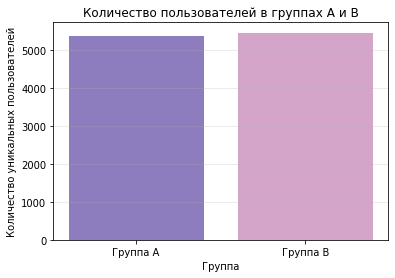

In [20]:
# строим столбчатую диаграмму
plt.bar(
    ['Группа A', 'Группа B'],
    [test_part_A, test_part_B],
    color=['#8E7DBE', '#D4A5C9']  
)

plt.title('Количество пользователей в группах A и B')
plt.xlabel('Группа')
plt.ylabel('Количество уникальных пользователей')

plt.grid(axis='y', alpha=0.3)

plt.show()

В тесте `interface_eu_test` участвуют 10 850 пользователей, в группе **А 5383 уникальных пользователей**, а в группе **B — 5467**. Распределение по группам практически равномерное: **процентная разница составляет — 1.56%**.<br> Существенного дисбаланса между группами не наблюдается.

- Рассчитаем количество пользователей, которые встречаются одновременно в группах A и B, или убедимся, что таких нет.

In [21]:
# пользователи группы A
users_a = set(test_participants[test_participants['group'] == 'A']['user_id'])

# пользователи группы B
users_b = set(test_participants[test_participants['group'] == 'B']['user_id'])

# пересечение групп
intersection = users_a & users_b

print(f'Количество пользователей, попавших в обе группы: {len(intersection)}')

Количество пользователей, попавших в обе группы: 0


- Ищем пересечения с конкурирующим тестом

In [22]:
# пользователи из теста interface_eu_test
users_1 = set(participants[participants['ab_test'] == 'interface_eu_test']['user_id'])

# пользователи из теста recommender_system_test
users_2 = set(participants[participants['ab_test'] == 'recommender_system_test']['user_id'])

# проверяем пересечение пользователей между двумя тестами

intersection = users_1 & users_2
print(f'Количество пользователей, попавших в оба теста: {len(intersection)}')

Количество пользователей, попавших в оба теста: 887


In [23]:
# исключаем из нашего теста пользователей, участвовавших в конкурирующем тесте
test_participants_clean = test_participants[~test_participants['user_id'].isin(intersection)]

# проверяем количество участников в каждой группе после исключения пересечений
test_participants_clean.groupby('group')['user_id'].nunique()

group
A    4952
B    5011
Name: user_id, dtype: int64

В группе A и группе B нет пользователей, которые одновременно участвуют в обеих группах. При этом обнаружено 887 пользователей, участвующих одновременно в `interface_eu_test` и конкурирующем `recommender_system_test`. Этих пользователей исключили из дальнейшего анализа. После исключения пересечений в изучаемом тесте осталось 9 963 участника.

3\.2 Проанализируем данные о пользовательской активности по таблице `ab_test_events`:

- оставим только события, связанные с участвующими в изучаемом тесте пользователями;

In [24]:
# оставляем только события пользователей, участвующих в нашем тесте
test_user_ids = set(test_participants_clean['user_id'])

test_events = events[events['user_id'].isin(test_user_ids)]

# проверяем количество пользователей и событий после фильтрации
print(f"Уникальных пользователей: {test_events['user_id'].nunique()}")
print(f"Количество событий: {len(test_events)}")

Уникальных пользователей: 9963
Количество событий: 68074


- определим горизонт анализа: рассчитаем время (лайфтайм) совершения события пользователем после регистрации и оставим только те события, которые были выполнены в течение первых семи дней с момента регистрации;

In [25]:
# получаем дату регистрации каждого пользователя
registrations = test_events[
    test_events['event_name'] == 'registration'
][['user_id', 'event_dt']].rename(
    columns={'event_dt': 'registration_dt'})

# добавляем дату регистрации к каждому событию пользователя
test_events = test_events.merge(
    registrations,
    on='user_id',
    how='left')

test_events['lifetime'] = test_events['event_dt'] - test_events['registration_dt']

# оставляем события, произошедшие в первые 7 дней после регистрации
test_events = test_events[
(test_events['lifetime'] >= pd.Timedelta(0)) &
(test_events['lifetime'] < pd.Timedelta(days=7))]

# проверяем количество событий после ограничения горизонта анализа
print(f"Количество событий за первые 7 дней: {len(test_events)}")

Количество событий за первые 7 дней: 58692


In [26]:
test_events

,user_id,event_dt,event_name,details,registration_dt,lifetime
0,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0,2020-12-06 14:10:01,0 days 00:00:00
1,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8,2020-12-06 14:37:25,0 days 00:00:00
2,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32,2020-12-06 17:20:22,0 days 00:00:00
3,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48,2020-12-06 19:36:54,0 days 00:00:00
4,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0,2020-12-06 19:42:20,0 days 00:00:00
...,...,...,...,...,...,...
67935,E89AF4EFC757D283,2020-12-29 21:46:43,product_cart,NaN,2020-12-23 09:35:48,6 days 12:10:55
67938,E89AF4EFC757D283,2020-12-29 21:47:56,product_cart,NaN,2020-12-23 09:35:48,6 days 12:12:08
68001,A6AFDC94A0D3B23D,2020-12-29 22:47:00,product_page,NaN,2020-12-23 13:53:33,6 days 08:53:27
68005,A6AFDC94A0D3B23D,2020-12-29 22:48:46,product_page,NaN,2020-12-23 13:53:33,6 days 08:55:13


После расчёта `lifetime` были отобраны события, произошедшие в течение первых 7 дней с момента регистрации пользователя. В выборке осталось **58 692 события**, которые будут использованы для дальнейшего анализа пользовательской активности.

Оценим достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%.

In [27]:
# задаем параметры
alpha = 0.05
beta = 0.2
power = 0.8
p = 0.3
mde = 0.03

effect_size = proportion_effectsize(p, p + mde)

power_analysis = NormalIndPower()

# рассчитываем необходимый размер выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    alpha = alpha,
    power=power,
    ratio = 1
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 3761


Выборка достаточна: необходимый размер — 3761 пользователь на группу, фактический размер групп A и B составляет 4952 и 5011 пользователей соответственно.

- рассчитаем для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

In [28]:
# добавляем информацию о группе к событиям пользователей
test_events = test_events.merge(
    test_participants_clean[['user_id', 'group']],
    on='user_id',
    how='left')

# считаем общее количество посетителей в каждой группе
visitors = test_events.groupby('group')['user_id'].nunique()

# считаем общее количество посетителей, сделавших покупку
buyers = (
    test_events[test_events['event_name'] == 'purchase']
    .groupby('group')['user_id'].nunique())
    
# рассчитываем конверсию в покупку
conversion = round(buyers/visitors * 100,2)
    
# объединяем результаты в одну таблицу
group_stats = pd.DataFrame({
    'visitors': visitors,
    'buyers': buyers,
    'conversion': conversion
})

group_stats

,visitors,buyers,conversion
group,,,
A,4952,1377,27.81
B,5011,1480,29.54


В контрольной **группе A** покупку совершили 1377 пользователей из 4952, что составляет **27,81%**.<br> В тестовой **группе B** покупку совершили 1480 пользователей из 5011, или **29,54%**.<br>Таким образом, в группе B количество покупателей **увеличилось на 103 человека**, а конверсия выросла на 1,73 п.п. по сравнению с группой A.<br>На предварительном уровне это говорит о положительной динамике в тестовой группе, однако для определения статистической значимости различия необходимо провести статистический тест.

## 4. Оценка результатов A/B-тестирования:

**H0**: доля пользователей, совершивших покупку, в группах A и B одинакова.<br>
**H1**: доля пользователей, совершивших покупку, в группах A и B различается.

In [29]:
# проводим Z-тест пропорций
m_a, m_b = [buyers['A'],  buyers['B']]
n_a, n_b = [visitors['A'],  visitors['B']]

alpha = 0.05

stat, p_value = proportions_ztest(
    [m_a, m_b], 
    [n_a, n_b],
    alternative='two-sided'
)

if p_value > alpha:
    print(f'pvalue={p_value} > {alpha}')
    print('Не отвергаем нулевую гипотезу')
else:
    print(f'pvalue={p_value} < {alpha}')
    print('Отвергаем нулевую гипотезу')

pvalue=0.05652509442458425 > 0.05
Не отвергаем нулевую гипотезу


**Вывод**: по результатам A/B-тестирования конверсия в тестовой группе B увеличилась с 27,81% до 29,54%, то есть на 1,73 п.п. по сравнению с контрольной группой A. Однако проведённый Z-тест показал, что это различие статистически незначимо (p-value = 0,0565 > 0,05). Кроме того, полученный прирост меньше ожидаемого эффекта в 3 п.п.<br> Таким образом, статистически подтверждённого улучшения конверсии после изменения интерфейса не выявлено, и **ожидаемый эффект** от A/B-тестирования **достигнут не был.**